# Penghilangan Kabut pada Citra (Image Dehazing) dengan Dark Channel Prior — Implementasi *From Scratch*
### Perbandingan dengan CLAHE dan Analisis Keterbatasan

**Mata Kuliah:** Visi Komputer — Project Akhir Semester 2025/2026

**Nama:** Ikrar Gempur Tirani   
**NIM:** D121231015

---
Seluruh algoritma ditulis **from scratch** dengan **numpy** saja. **Matplotlib** hanya untuk menampilkan, dan **PIL** hanya untuk *membaca berkas* gambar (decode JPEG = I/O, bukan algoritma). **Tidak ada** OpenCV, scipy, maupun scikit-image. Yang diimplementasikan sendiri: min-filter (erosi), box-filter (integral image), Dark Channel Prior, guided filter, CLAHE, PSNR, SSIM, entropi, rgb2gray, dan resize bilinear.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image   # HANYA untuk decode berkas gambar (I/O), bukan algoritma

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print("Komputasi: numpy murni | Tampilan: matplotlib | Baca berkas: PIL.")
print("Tanpa OpenCV / scipy / scikit-image.")

Komputasi: numpy murni | Tampilan: matplotlib | Baca berkas: PIL.
Tanpa OpenCV / scipy / scikit-image.


## 1. Teori Singkat

**Model hamburan atmosfer:**

$$I(x) = J(x)\,t(x) + A\,(1 - t(x))$$

dengan $I$ citra berkabut, $J$ citra jernih, $t(x)$ transmission, $A$ atmospheric light.

**Dark Channel Prior:** pada citra outdoor bebas kabut, tiap patch lokal hampir selalu punya piksel bernilai sangat kecil di salah satu kanal:

$$J^{dark}(x) = \min_{c}\left(\min_{y\in\Omega(x)} J^c(y)\right) \approx 0$$

Operasi minimum lokal ini = erosi (minimum filter). Dari prior ini transmission diestimasi dan citra dipulihkan dengan membalik model di atas.

## 2. Fungsi Dasar (from scratch)

Primitif berikut menggantikan fungsi library. Semua hanya memakai numpy.

**(a) rgb2gray** — luminansi Rec.709.

In [2]:
def rgb2gray(img):
    return 0.2125 * img[..., 0] + 0.7154 * img[..., 1] + 0.0721 * img[..., 2]

**(b) resize bilinear** — interpolasi dua-linear (untuk memperkecil citra besar).

In [3]:
def resize_bilinear(img, new_w):
    H, W = img.shape[:2]
    new_h = int(round(H * new_w / W))
    ys = (np.arange(new_h) + 0.5) * H / new_h - 0.5
    xs = (np.arange(new_w) + 0.5) * W / new_w - 0.5
    ys = np.clip(ys, 0, H - 1); xs = np.clip(xs, 0, W - 1)
    y0 = np.floor(ys).astype(int); x0 = np.floor(xs).astype(int)
    y1 = np.minimum(y0 + 1, H - 1); x1 = np.minimum(x0 + 1, W - 1)
    wy = (ys - y0)[:, None, None]; wx = (xs - x0)[None, :, None]
    if img.ndim == 2:
        img = img[..., None]; squeeze = True
    else:
        squeeze = False
    top = img[y0][:, x0] * (1 - wx) + img[y0][:, x1] * wx
    bot = img[y1][:, x0] * (1 - wx) + img[y1][:, x1] * wx
    out = top * (1 - wy) + bot * wy
    return out[..., 0] if squeeze else out

**(c) min-filter (erosi)** — minimum jendela kotak, dihitung separable (1D dua kali).

In [4]:
def _min_1d(a, size, axis):
    r = size // 2
    a = np.swapaxes(a, axis, -1)
    pad = np.pad(a, [(0, 0)] * (a.ndim - 1) + [(r, size - 1 - r)], mode='edge')
    n = a.shape[-1]
    out = pad[..., :n].copy()
    for k in range(1, size):
        np.minimum(out, pad[..., k:k + n], out=out)
    return np.swapaxes(out, axis, -1)

def min_filter_2d(a, size):
    return _min_1d(_min_1d(a, size, 0), size, 1)

**(d) box-filter (rata-rata lokal)** — via *integral image* (summed-area table), kompleksitas linear.

In [5]:
def box_mean(a, radius):
    k = 2 * radius + 1
    pad = np.pad(a, radius, mode='edge')
    cs = np.cumsum(pad, axis=0)
    cs = np.vstack([np.zeros((1, cs.shape[1])), cs])
    col = cs[k:, :] - cs[:-k, :]
    cs2 = np.cumsum(col, axis=1)
    cs2 = np.hstack([np.zeros((cs2.shape[0], 1)), cs2])
    s = cs2[:, k:] - cs2[:, :-k]
    return s / (k * k)

## 3. Load Citra & Sintesis Kabut (Ground Truth)

Kabut disintesis sendiri di atas citra jernih (cityscape cerah) memakai model atmosfer, sehingga PSNR/SSIM bisa dihitung terhadap aslinya. PIL dipakai hanya untuk membaca berkas.

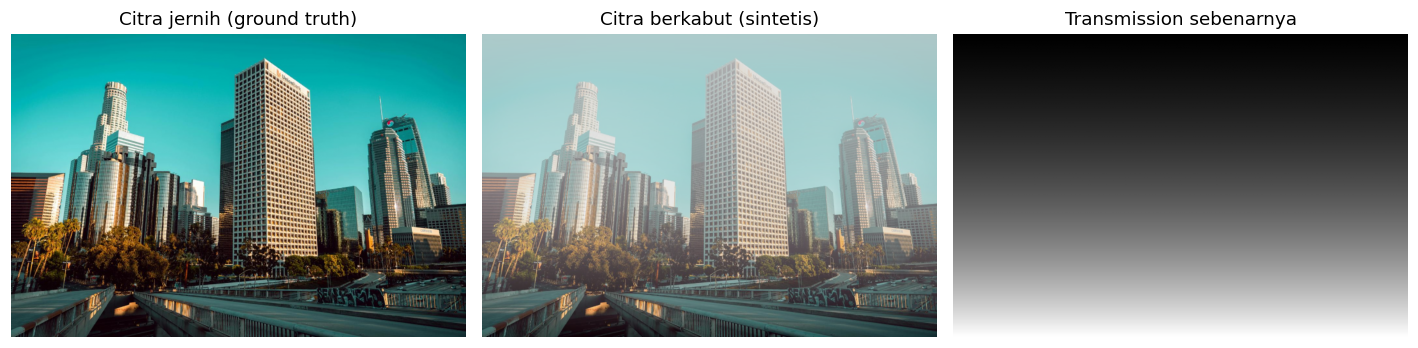

A sebenarnya = [0.85 0.85 0.85]


In [6]:
def load_image(path, max_w=900):
    im = np.asarray(Image.open(path).convert('RGB'), dtype=np.float64) / 255.0
    if max_w and im.shape[1] > max_w:
        im = resize_bilinear(im, max_w)
    return im

def synthesize_haze(J, beta=1.6, A_val=0.85):
    H, W = J.shape[:2]
    depth = np.linspace(1.0, 0.0, H)[:, None] * np.ones((1, W))  # makin atas makin jauh
    t = np.exp(-beta * depth)
    A = np.array([A_val, A_val, A_val])
    I = J * t[:, :, None] + A[None, None, :] * (1 - t[:, :, None])
    return np.clip(I, 0, 1), t, A

J_clear = load_image('gt_clear.jpg', 800)
I_hazy, t_true, A_true = synthesize_haze(J_clear, beta=1.6, A_val=0.85)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(J_clear);             ax[0].set_title("Citra jernih (ground truth)")
ax[1].imshow(I_hazy);              ax[1].set_title("Citra berkabut (sintetis)")
ax[2].imshow(t_true, cmap='gray'); ax[2].set_title("Transmission sebenarnya")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()
print("A sebenarnya =", A_true)

## 4. Dark Channel Prior (from scratch)

Memakai primitif `min_filter_2d` (erosi) dan `box_mean` (untuk guided filter).

**(a) Dark channel** — min antar-kanal lalu min lokal (erosi).

In [7]:
def dark_channel(img, patch=15):
    return min_filter_2d(np.min(img, axis=2), patch)

**(b) Atmospheric light A** — 0,1% piksel paling terang di dark channel, lalu yang paling terang di citra asli.

In [8]:
def atmospheric_light(img, dark, top_frac=0.001):
    H, W = dark.shape
    n = max(1, int(H * W * top_frac))
    idx = np.argsort(dark.ravel())[-n:]
    cand = img.reshape(-1, 3)[idx]
    return cand[np.argmax(cand.sum(axis=1))]

**(c) Transmission kasar** — langsung dari prior.

In [9]:
def estimate_transmission(img, A, omega=0.95, patch=15):
    return 1.0 - omega * dark_channel(img / A[None, None, :], patch)

**(d) Guided filter** — refinement transmission via model linear lokal; box-mean dari fungsi sendiri.

In [10]:
def guided_filter(I, p, r=40, eps=1e-3):
    mI = box_mean(I, r); mp = box_mean(p, r)
    mIp = box_mean(I * p, r); cov = mIp - mI * mp
    mII = box_mean(I * I, r); var = mII - mI * mI
    a = cov / (var + eps); b = mp - a * mI
    return box_mean(a, r) * I + box_mean(b, r)

**(e) Recovery + pipeline DCP.**

In [11]:
def recover(img, A, t, t0=0.1):
    t = np.maximum(t, t0)
    return np.clip((img - A[None, None, :]) / t[:, :, None] + A[None, None, :], 0, 1)

def dehaze_dcp(I, patch=15, omega=0.95, t0=0.1, r=40, eps=1e-3):
    dark = dark_channel(I, patch)
    A = atmospheric_light(I, dark)
    t_coarse = estimate_transmission(I, A, omega, patch)
    t_ref = np.clip(guided_filter(rgb2gray(I), t_coarse, r, eps), 0, 1)
    return recover(I, A, t_ref, t0), dark, A, t_coarse, t_ref

## 5. Baseline CLAHE (from scratch)

CLAHE diterapkan pada kanal luminansi (Y dari YCbCr). Tahapannya: citra dibagi menjadi *tiles*; tiap tile dibuat histogram, di-*clip* pada batas tertentu (kelebihannya disebar merata), lalu CDF-nya menjadi peta intensitas (LUT). Tiap piksel diinterpolasi **bilinear** antar LUT tetangga agar mulus tanpa batas blok.

In [12]:
def _ycbcr(img):
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    Y = 0.299 * R + 0.587 * G + 0.114 * B
    Cb = 0.5 - 0.168736 * R - 0.331264 * G + 0.5 * B
    Cr = 0.5 + 0.5 * R - 0.418688 * G - 0.081312 * B
    return Y, Cb, Cr

def _ycbcr2rgb(Y, Cb, Cr):
    R = Y + 1.402 * (Cr - 0.5)
    G = Y - 0.344136 * (Cb - 0.5) - 0.714136 * (Cr - 0.5)
    B = Y + 1.772 * (Cb - 0.5)
    return np.clip(np.stack([R, G, B], -1), 0, 1)

def clahe_gray(ch, grid=8, clip=2.0, nbins=256):
    H, W = ch.shape
    q = np.clip((ch * (nbins - 1)).round().astype(int), 0, nbins - 1)
    ys = np.linspace(0, H, grid + 1).astype(int)
    xs = np.linspace(0, W, grid + 1).astype(int)
    luts = np.zeros((grid, grid, nbins))
    for ty in range(grid):
        for tx in range(grid):
            tile = q[ys[ty]:ys[ty + 1], xs[tx]:xs[tx + 1]]
            hist = np.bincount(tile.ravel(), minlength=nbins).astype(float)
            n = max(1, tile.size)
            climit = max(1.0, clip * n / nbins)              # batas clip
            excess = np.maximum(hist - climit, 0).sum()      # kelebihan
            hist = np.minimum(hist, climit) + excess / nbins # sebar merata
            cdf = np.cumsum(hist)
            cdf = (cdf - cdf.min()) / (cdf.max() - cdf.min() + 1e-12)
            luts[ty, tx] = cdf                               # LUT tile
    cy = (ys[:-1] + ys[1:]) / 2.0; cx = (xs[:-1] + xs[1:]) / 2.0
    yy = np.arange(H); xx = np.arange(W)
    iy = np.clip(np.searchsorted(cy, yy) - 1, 0, grid - 1); iy1 = np.clip(iy + 1, 0, grid - 1)
    wy = np.clip(np.where(iy1 > iy, (yy - cy[iy]) / (cy[iy1] - cy[iy] + 1e-12), 0.0), 0, 1)[:, None]
    ix = np.clip(np.searchsorted(cx, xx) - 1, 0, grid - 1); ix1 = np.clip(ix + 1, 0, grid - 1)
    wx = np.clip(np.where(ix1 > ix, (xx - cx[ix]) / (cx[ix1] - cx[ix] + 1e-12), 0.0), 0, 1)[None, :]
    IY = iy[:, None]; IY1 = iy1[:, None]; IX = ix[None, :]; IX1 = ix1[None, :]
    v00 = luts[IY, IX, q]; v01 = luts[IY, IX1, q]; v10 = luts[IY1, IX, q]; v11 = luts[IY1, IX1, q]
    top = v00 * (1 - wx) + v01 * wx; bot = v10 * (1 - wx) + v11 * wx
    return np.clip(top * (1 - wy) + bot * wy, 0, 1)

def clahe(img, grid=8, clip=2.0):
    Y, Cb, Cr = _ycbcr(img)
    return _ycbcr2rgb(clahe_gray(Y, grid, clip), Cb, Cr)

## 6. Metrik (from scratch)

PSNR dan SSIM ditulis sendiri. SSIM memakai jendela seragam 7×7 (lewat `box_mean`) dengan kovarians sampel.

In [13]:
def psnr(a, b):
    mse = np.mean((a - b) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(1.0 / mse)

def _ssim_ch(a, b, win=7, C1=0.01 ** 2, C2=0.03 ** 2):
    r = win // 2
    mu_a = box_mean(a, r); mu_b = box_mean(b, r)
    mu_a2 = mu_a * mu_a; mu_b2 = mu_b * mu_b; mu_ab = mu_a * mu_b
    NP = win * win; cn = NP / (NP - 1)
    va = (box_mean(a * a, r) - mu_a2) * cn
    vb = (box_mean(b * b, r) - mu_b2) * cn
    vab = (box_mean(a * b, r) - mu_ab) * cn
    smap = ((2 * mu_ab + C1) * (2 * vab + C2)) / ((mu_a2 + mu_b2 + C1) * (va + vb + C2))
    return smap[r:-r, r:-r].mean()

def ssim(a, b, win=7):
    return float(np.mean([_ssim_ch(a[..., c], b[..., c], win) for c in range(a.shape[2])]))

def avg_gradient(im):
    g = rgb2gray(im); gy, gx = np.gradient(g)
    return float(np.mean(np.sqrt(gx ** 2 + gy ** 2)))

## 7. Jalankan & Bandingkan Hasil

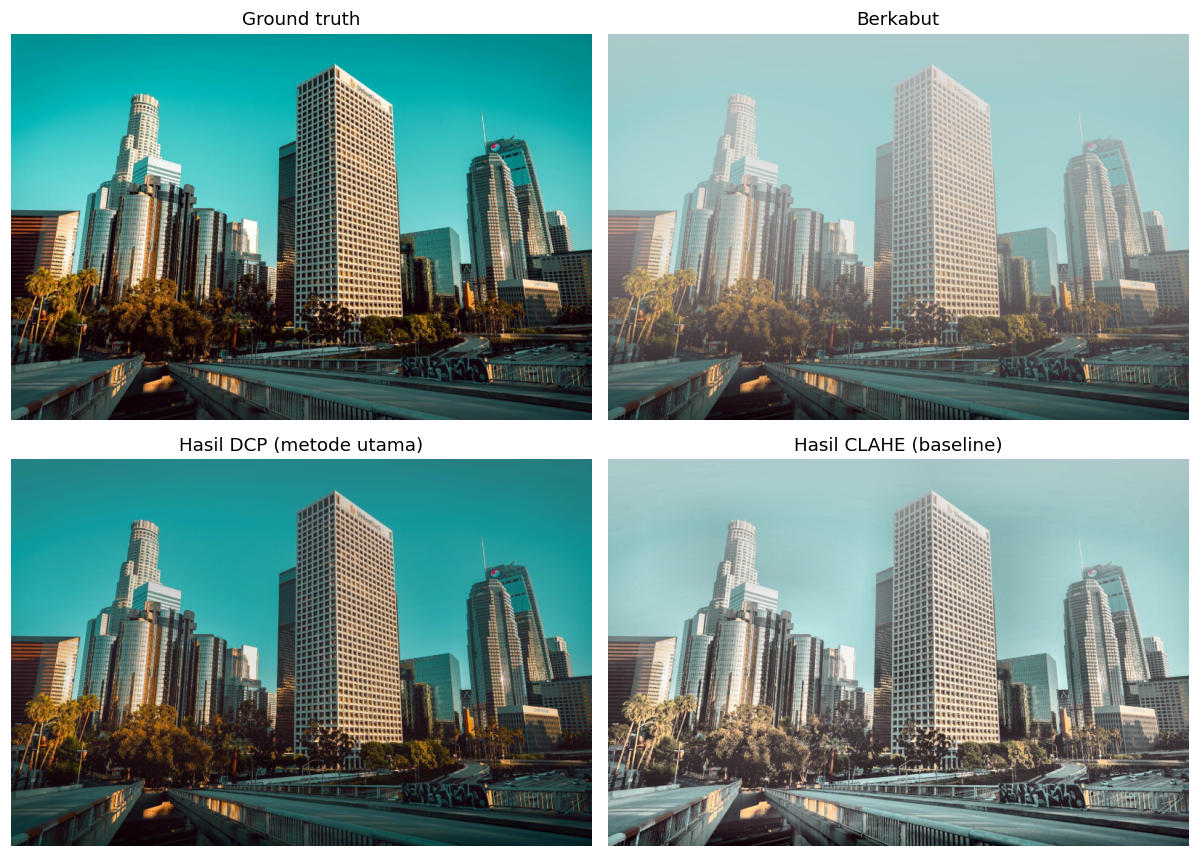

A sebenarnya: [0.85 0.85 0.85]  | A estimasi DCP: [0.915 0.918 0.913]


In [14]:
J_dcp, dark, A_est, t_coarse, t_ref = dehaze_dcp(I_hazy)
J_clahe = clahe(I_hazy)

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0,0].imshow(J_clear); ax[0,0].set_title("Ground truth")
ax[0,1].imshow(I_hazy);  ax[0,1].set_title("Berkabut")
ax[1,0].imshow(J_dcp);   ax[1,0].set_title("Hasil DCP (metode utama)")
ax[1,1].imshow(J_clahe); ax[1,1].set_title("Hasil CLAHE (baseline)")
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()
print("A sebenarnya:", np.round(A_true,3), " | A estimasi DCP:", np.round(A_est,3))

## 8. Visualisasi Tahap Antara

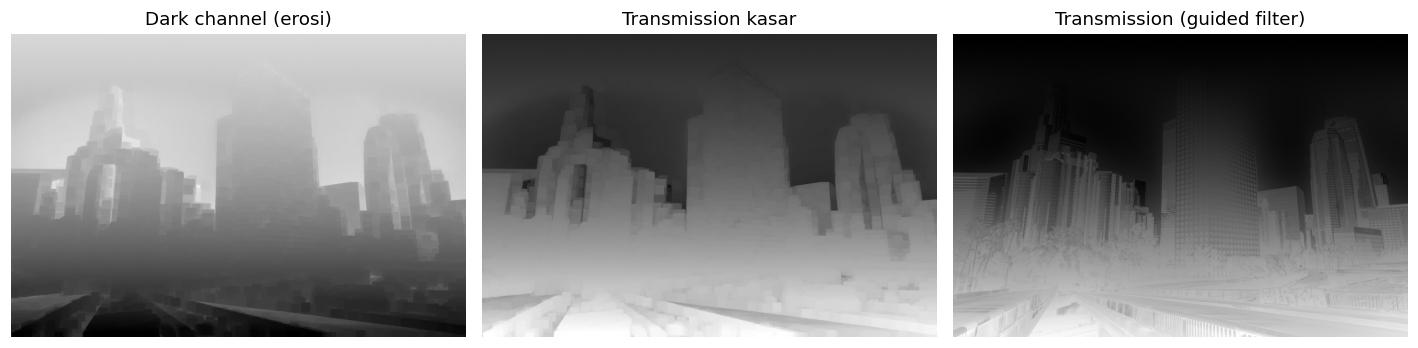

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(dark, cmap='gray');     ax[0].set_title("Dark channel (erosi)")
ax[1].imshow(t_coarse, cmap='gray'); ax[1].set_title("Transmission kasar")
ax[2].imshow(t_ref, cmap='gray');    ax[2].set_title("Transmission (guided filter)")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 9. Evaluasi Kuantitatif (PSNR & SSIM terhadap ground truth)

Metode                         PSNR (dB)      SSIM
--------------------------------------------------
Berkabut (tanpa proses)            11.38    0.7031
CLAHE (baseline)                   11.97    0.7368
DCP (metode utama)                 22.79    0.9035


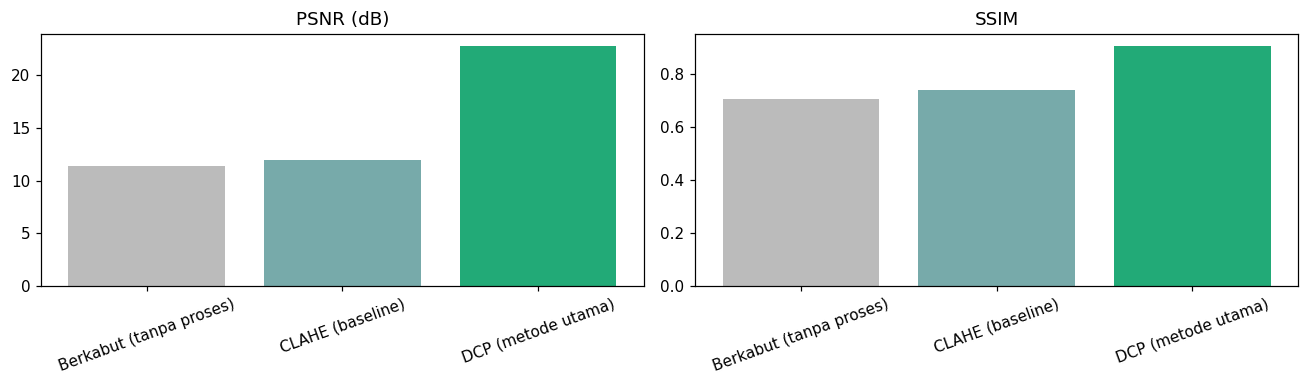

In [16]:
rows = [("Berkabut (tanpa proses)", psnr(J_clear, I_hazy),  ssim(J_clear, I_hazy)),
        ("CLAHE (baseline)",        psnr(J_clear, J_clahe), ssim(J_clear, J_clahe)),
        ("DCP (metode utama)",      psnr(J_clear, J_dcp),   ssim(J_clear, J_dcp))]
print(f"{'Metode':28s}{'PSNR (dB)':>12s}{'SSIM':>10s}")
print("-"*50)
for name, p, s in rows:
    print(f"{name:28s}{p:12.2f}{s:10.4f}")

labels = [r[0] for r in rows]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(labels, [r[1] for r in rows], color=['#bbb','#7aa','#2a7']); ax[0].set_title("PSNR (dB)")
ax[1].bar(labels, [r[2] for r in rows], color=['#bbb','#7aa','#2a7']); ax[1].set_title("SSIM")
for a in ax: a.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 10. Eksperimen Variasi Parameter

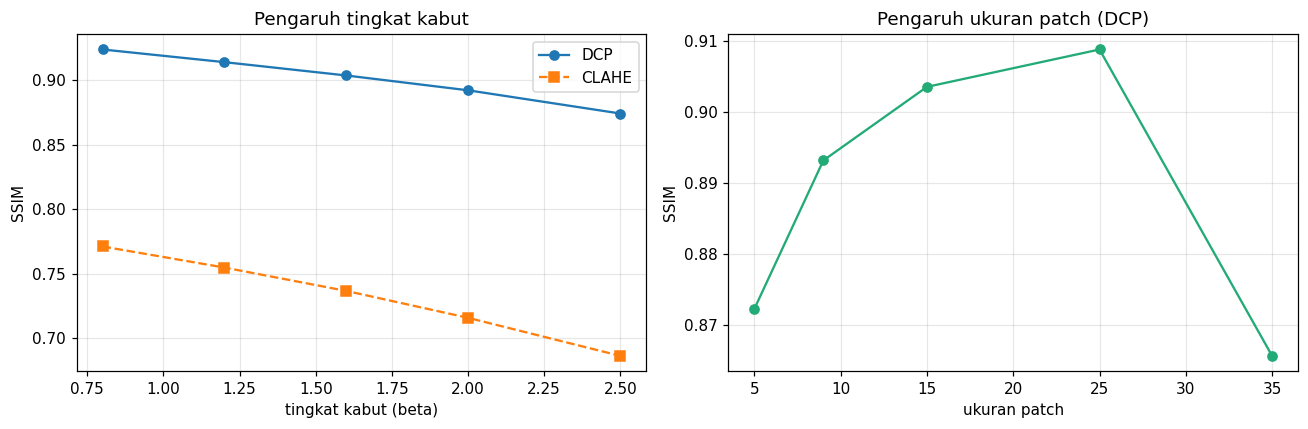

In [17]:
betas = [0.8, 1.2, 1.6, 2.0, 2.5]; dcp_s = []; clahe_s = []
for b in betas:
    Ib, _, _ = synthesize_haze(J_clear, beta=b, A_val=0.85)
    Jd, *_ = dehaze_dcp(Ib)
    dcp_s.append(ssim(J_clear, Jd)); clahe_s.append(ssim(J_clear, clahe(Ib)))
patches = [5, 9, 15, 25, 35]; patch_s = []
for ps in patches:
    Jd, *_ = dehaze_dcp(I_hazy, patch=ps); patch_s.append(ssim(J_clear, Jd))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(betas, dcp_s, 'o-', label='DCP'); ax[0].plot(betas, clahe_s, 's--', label='CLAHE')
ax[0].set_xlabel('tingkat kabut (beta)'); ax[0].set_ylabel('SSIM'); ax[0].set_title('Pengaruh tingkat kabut'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(patches, patch_s, 'o-', color='#2a7'); ax[1].set_xlabel('ukuran patch'); ax[1].set_ylabel('SSIM'); ax[1].set_title('Pengaruh ukuran patch (DCP)'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 11. Uji pada Citra Berkabut Nyata

Dua foto kabut nyata: **kota (keberhasilan)** dan **padang (keterbatasan)**. Tanpa ground truth, dipakai **gradien rata-rata** (ketajaman) sebagai indikator no-reference — diakui hanya indikatif.

Citra                        Gradien rata-rata
------------------------------------------------
Kota (keberhasilan)         0.0236 -> 0.0248


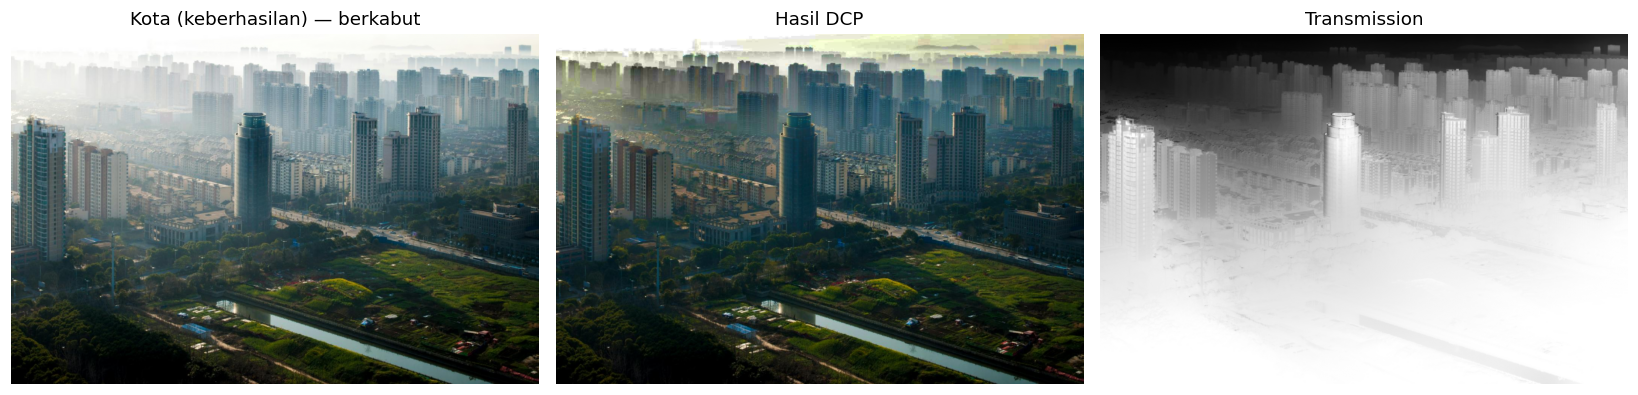

Padang (keterbatasan)       0.0127 -> 0.0122


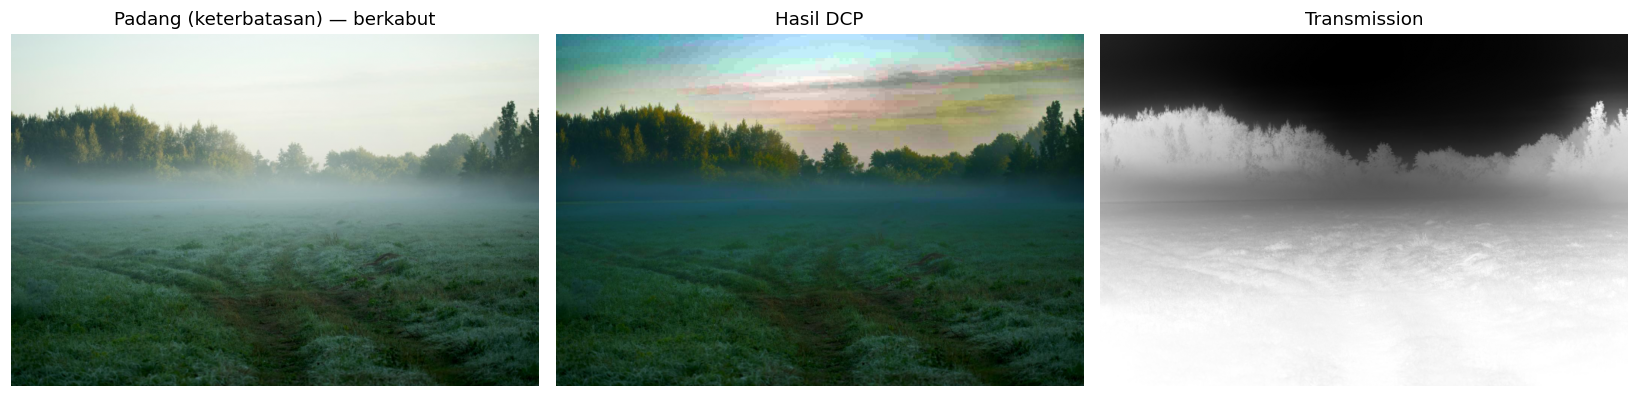


Kota: ketajaman naik -> detail pulih (berhasil).
Padang: ketajaman sedikit turun; area langit memunculkan artefak -> keterbatasan DCP.


In [18]:
print(f"{'Citra':24s}{'Gradien rata-rata':>22s}")
print("-"*48)
for path, judul in [("nyata_kota.jpg",   "Kota (keberhasilan)"),
                    ("nyata_padang.jpg", "Padang (keterbatasan)")]:
    real = load_image(path, 900)
    real_dcp, _, _, _, real_t = dehaze_dcp(real)
    g0, g1 = avg_gradient(real), avg_gradient(real_dcp)
    print(f"{judul:24s}{g0:10.4f} -> {g1:.4f}")
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].imshow(real);                 ax[0].set_title(judul + " — berkabut")
    ax[1].imshow(real_dcp);             ax[1].set_title("Hasil DCP")
    ax[2].imshow(real_t, cmap='gray');  ax[2].set_title("Transmission")
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()
print()
print("Kota: ketajaman naik -> detail pulih (berhasil).")
print("Padang: ketajaman sedikit turun; area langit memunculkan artefak -> keterbatasan DCP.")

## Kesimpulan Ringkas

- Seluruh algoritma (min-filter/erosi, box-filter, DCP, guided filter, CLAHE, PSNR, SSIM) diimplementasikan **from scratch** dengan numpy; tanpa OpenCV/scipy/skimage.
- DCP memulihkan citra berkabut jauh lebih baik daripada CLAHE pada citra sintetis (PSNR & SSIM naik tajam) karena memodelkan fisika kabut.
- Keterbatasan DCP: area langit/objek putih besar memicu artefak akibat transmission yang sangat rendah.
- Metrik tanpa-acuan (gradien) hanya indikatif; bukti tegas berasal dari eksperimen sintetis ber-ground-truth.